# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain

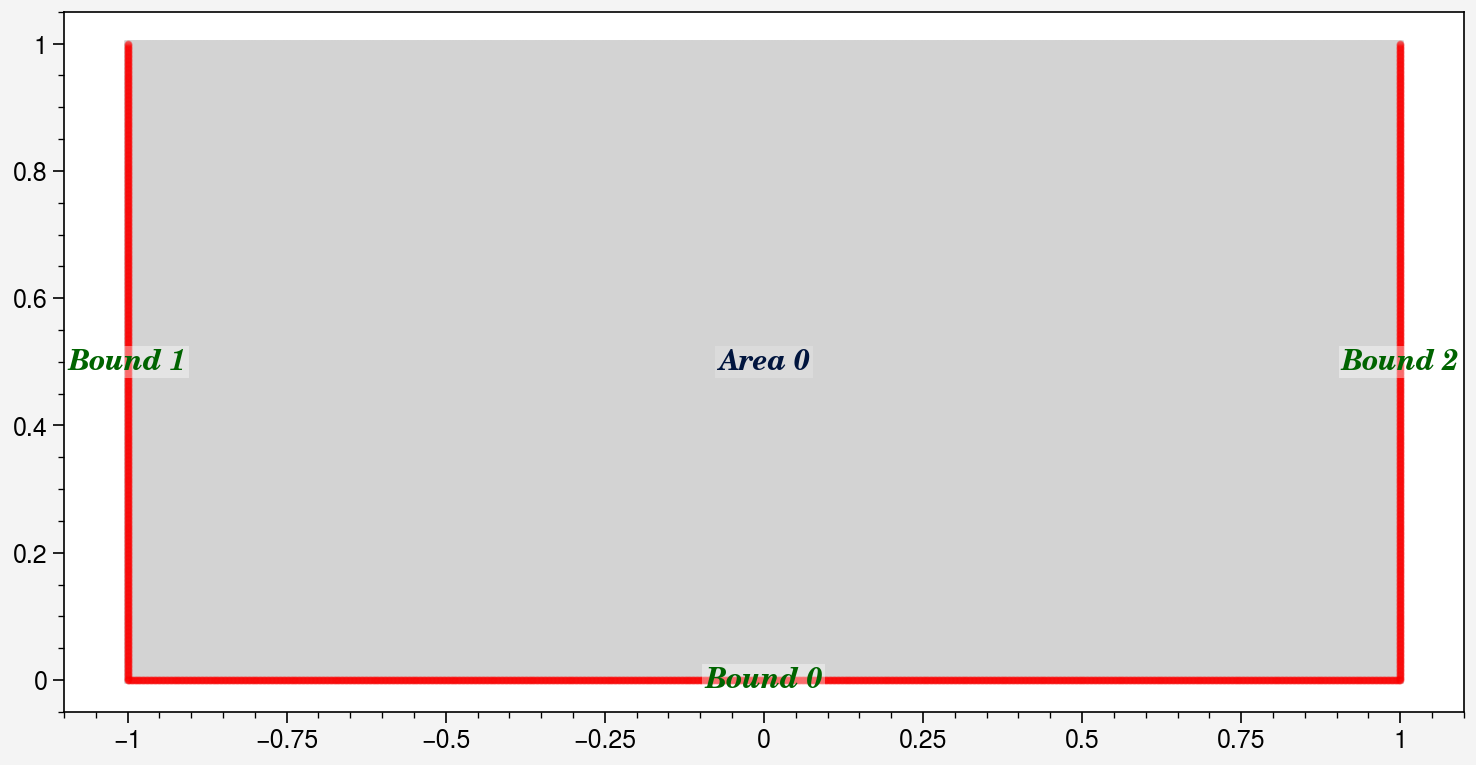

In [2]:
area = df.geometry.rectangle([-1, 1], [0, 1])
line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)
domain.show_setup()

## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [3]:
# Define PDE
from torch import sin, pi
domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})

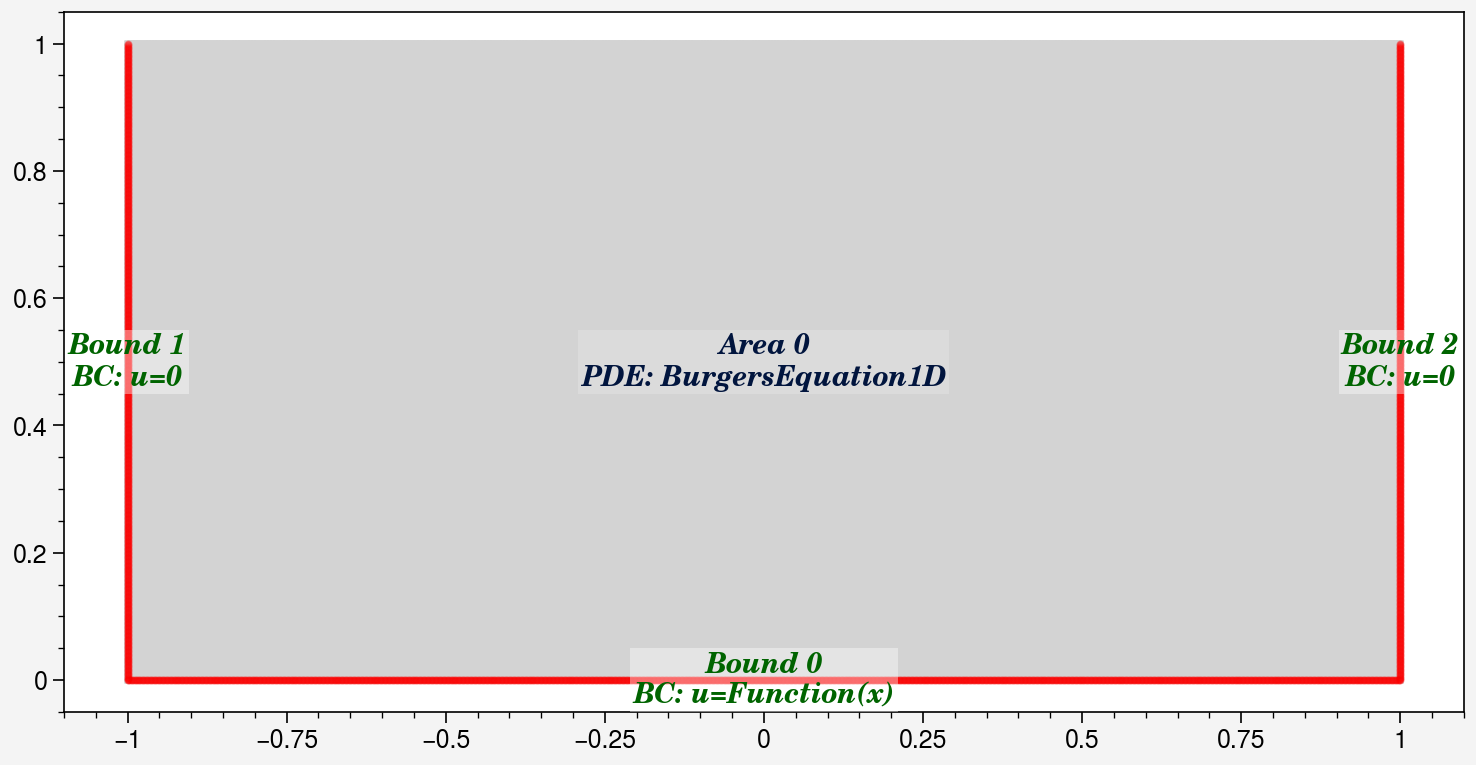

In [4]:
domain.show_setup()

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

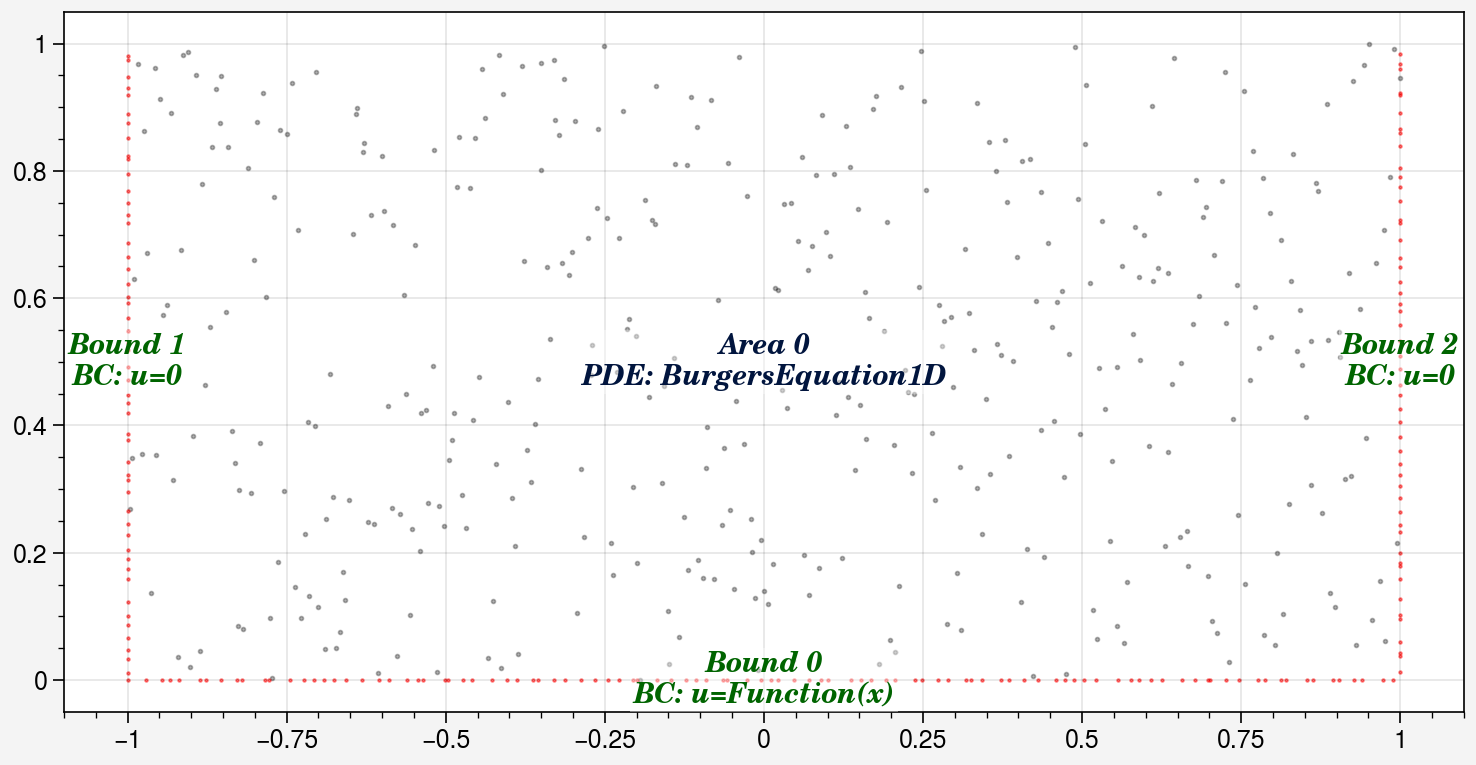

In [5]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([100, 50, 50], [400])
domain.show_coordinates(display_physics=True)

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

In [6]:
def do_in_adam(epoch, model):
    if epoch % 1 == 0 and epoch > 0:
        domain.sampling_R3([], [400])
        if epoch%500 == 0:
            print(domain)
            domain.show_coordinates()

def do_in_lbfgs(epoch, model):
    if epoch % 1 == 0 and epoch > 0:
        domain.sampling_R3([], [400])
        domain.sampling_lhs([100, 50, 50])
        if epoch%200 ==0:
            print(domain)
            domain.show_coordinates(display_resampling=True)

Train the model using Adam optimizer followed by L-BFGS optimizer.

In [7]:
model0 = df.PINN(input_vars=['x', 'y'], output_vars=['u'], width=16, length=4)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
    learning_rate=0.01,
    epochs=2000,
    do_between_epochs=do_in_adam,
    print_every=200)

Epoch: 1, total_loss: 0.65488, bc_loss: 0.65185, pde_loss: 0.00303
Epoch: 200, total_loss: 0.21086, bc_loss: 0.16081, pde_loss: 0.05006
Epoch: 400, total_loss: 0.18009, bc_loss: 0.11261, pde_loss: 0.06749
Training interrupted by user.


In [ ]:
# model2 = model1.train_lbfgs(calc_loss = df.calc_loss_weighted(domain, bc_weights=1), epochs=200, do_between_epochs=do_in_lbfgs)

## 4. Visualization

In [ ]:
import numpy as np
with open('../burger_sol/burgers_solution.txt', 'r') as f:
    data = np.loadtxt(f)
x, y, u = data[:, 0], data[:, 1], data[:, 2]

In [ ]:

import torch

domain_test = df.custom_data({'x':torch.tensor(x, dtype=torch.float32), 'y':torch.tensor(y, dtype=torch.float32)})

In [ ]:
# Evaluate the best model
prediction = domain_test.evaluate(model1)
# Sampling uniform points
import numpy as np

In [ ]:
prediction['u_sol'] = u
prediction['error'] = np.abs(prediction['u']-prediction['u_sol'])
print(np.mean(prediction['error']))

0.17363860197653563


### 4.1 Visualize PDE area

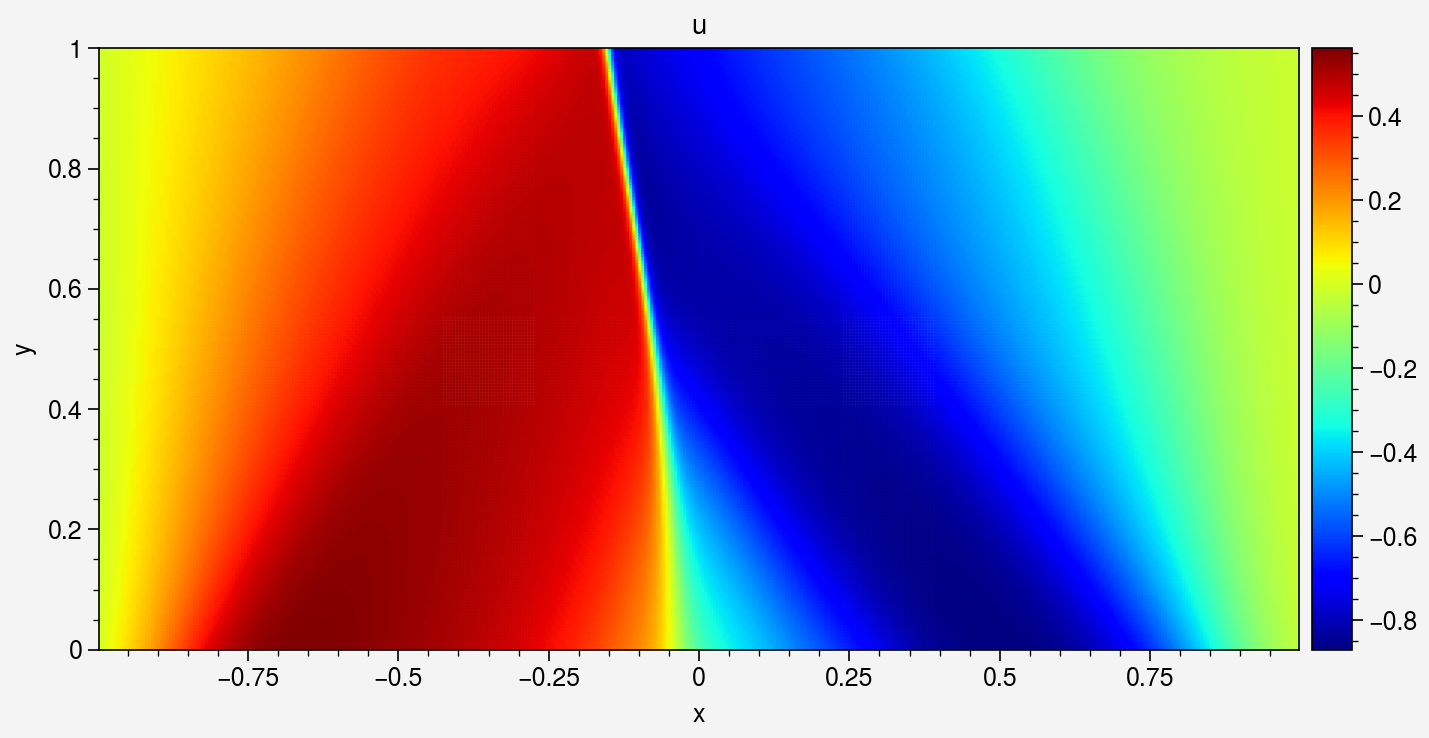

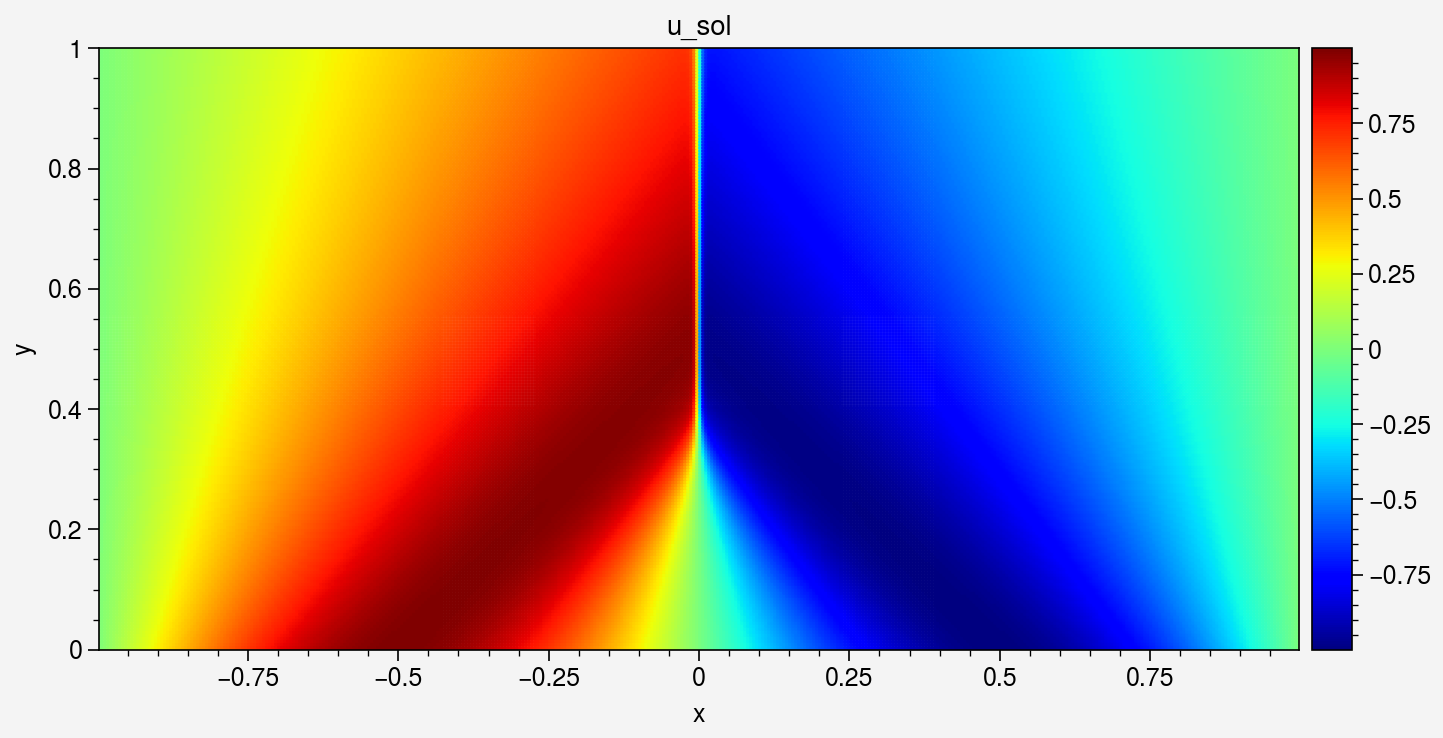

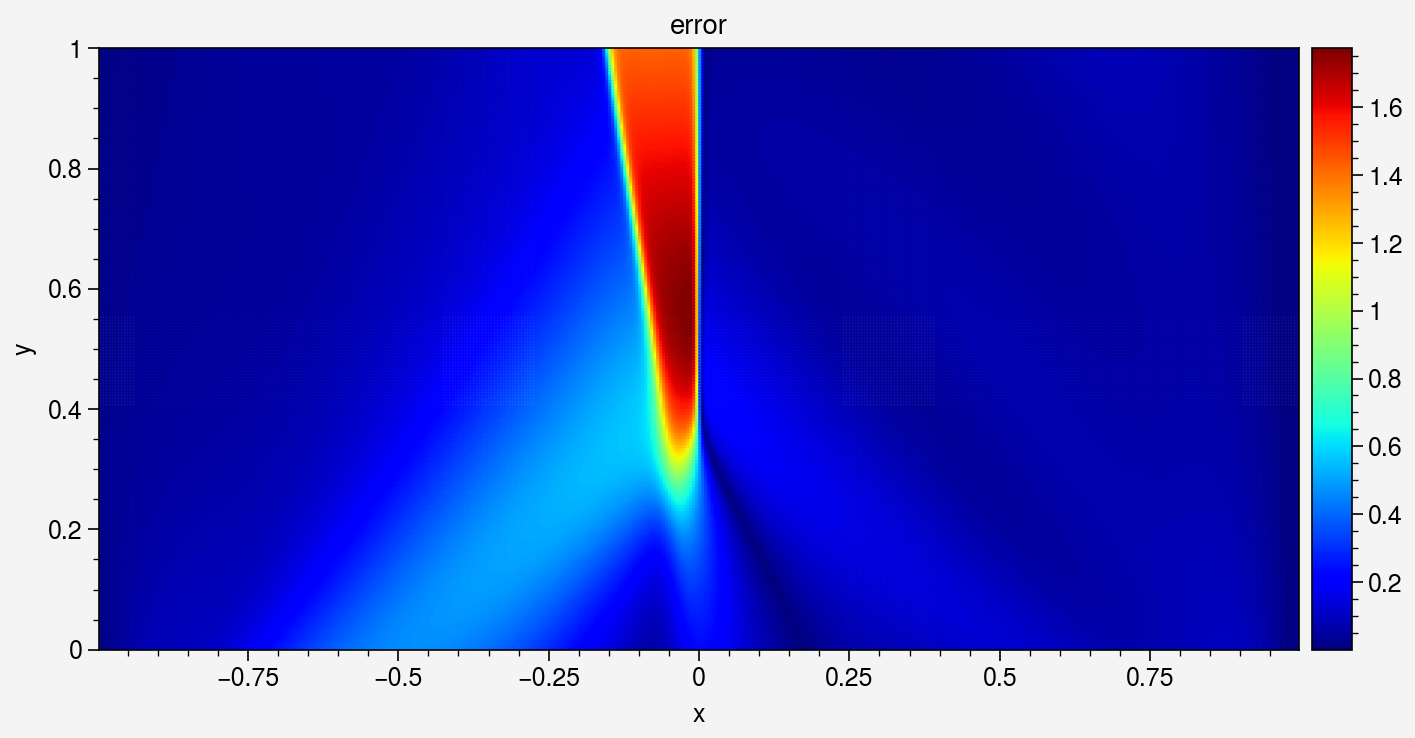

In [ ]:
# Plot Velocity Field
prediction.plot_color('u', cmap = 'jet', s=1).savefig('u_field.png')
prediction.plot_color('u_sol', cmap = 'jet', s=1).savefig('u_field.png')
prediction.plot_color('error', cmap = 'jet', s=1).savefig('u_field.png')

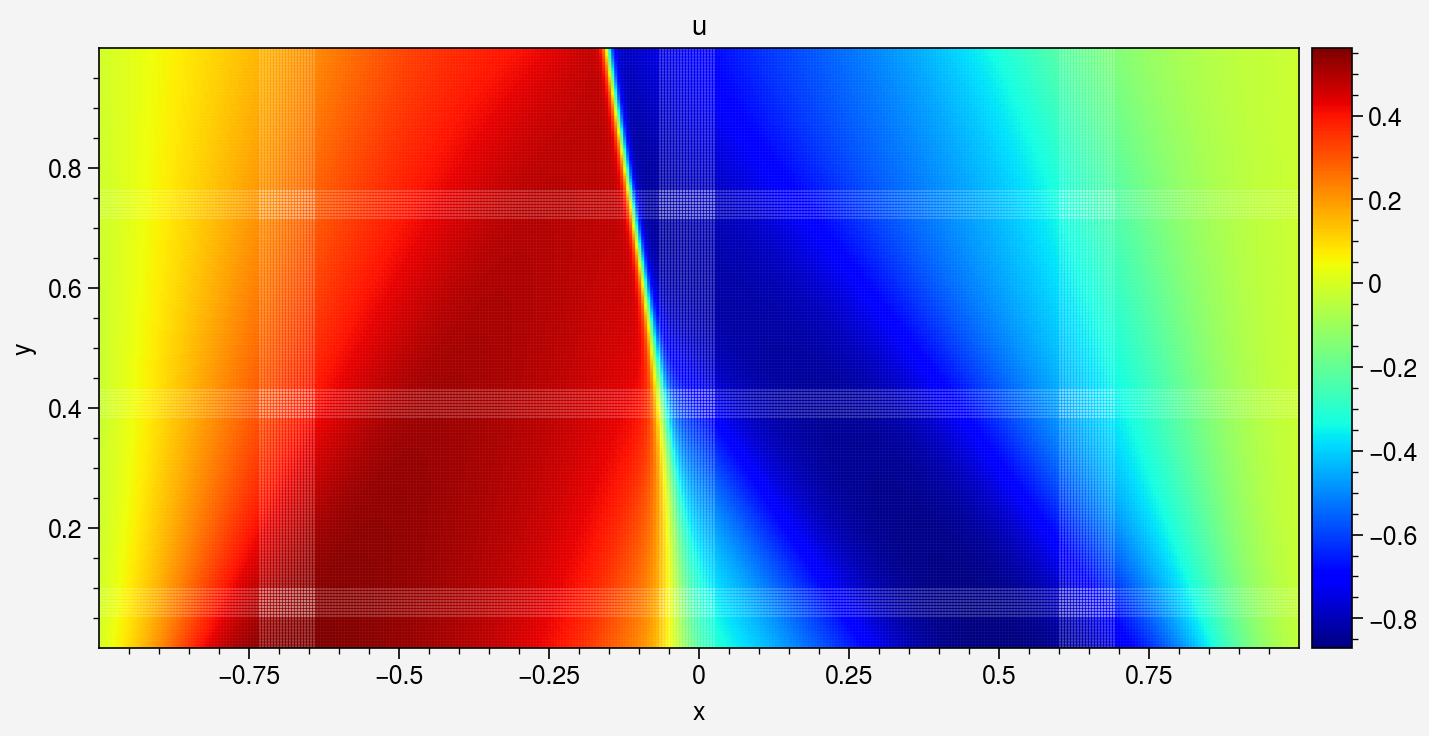

In [ ]:
pred = domain.area_list[0].evaluate(model1)
pred.sampling_area([400,200])
pred.plot_color('u', cmap = 'jet', s=0.45).savefig('u_field.png')

### 4.2 Visualize u at y = 0.75

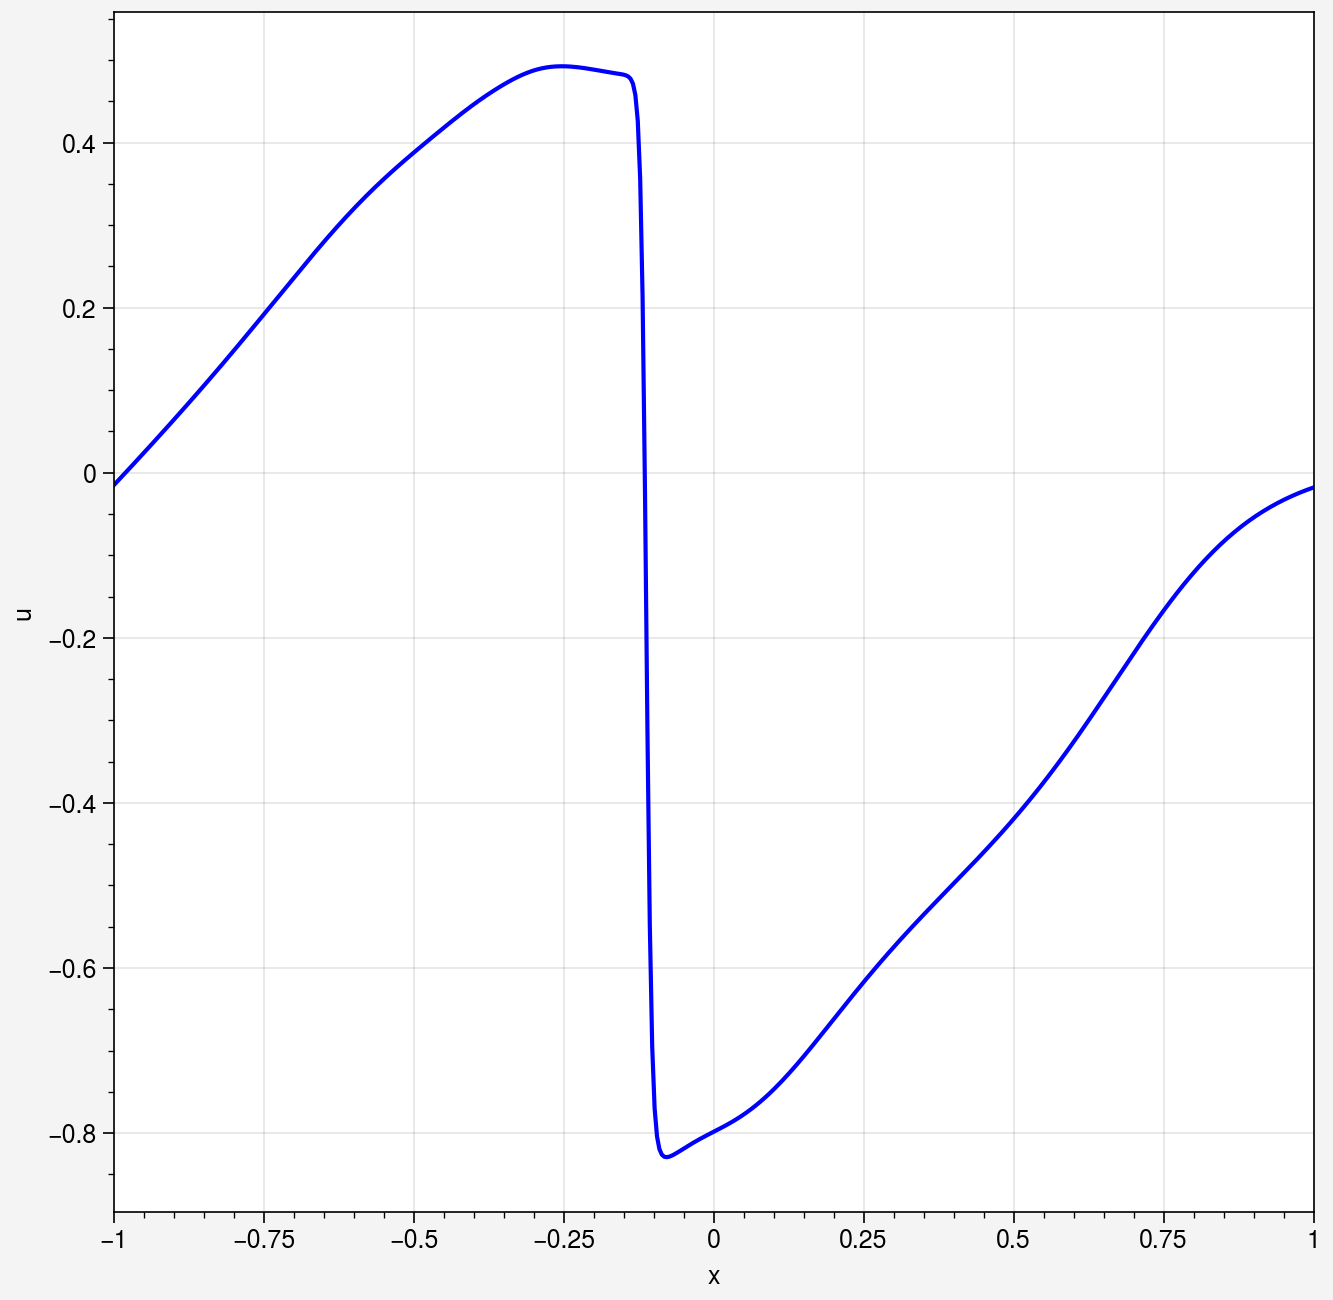

In [ ]:
line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
prediction = line.evaluate(model1)
prediction.sampling_line(500)
_ = prediction.plot(y_axis = 'u')

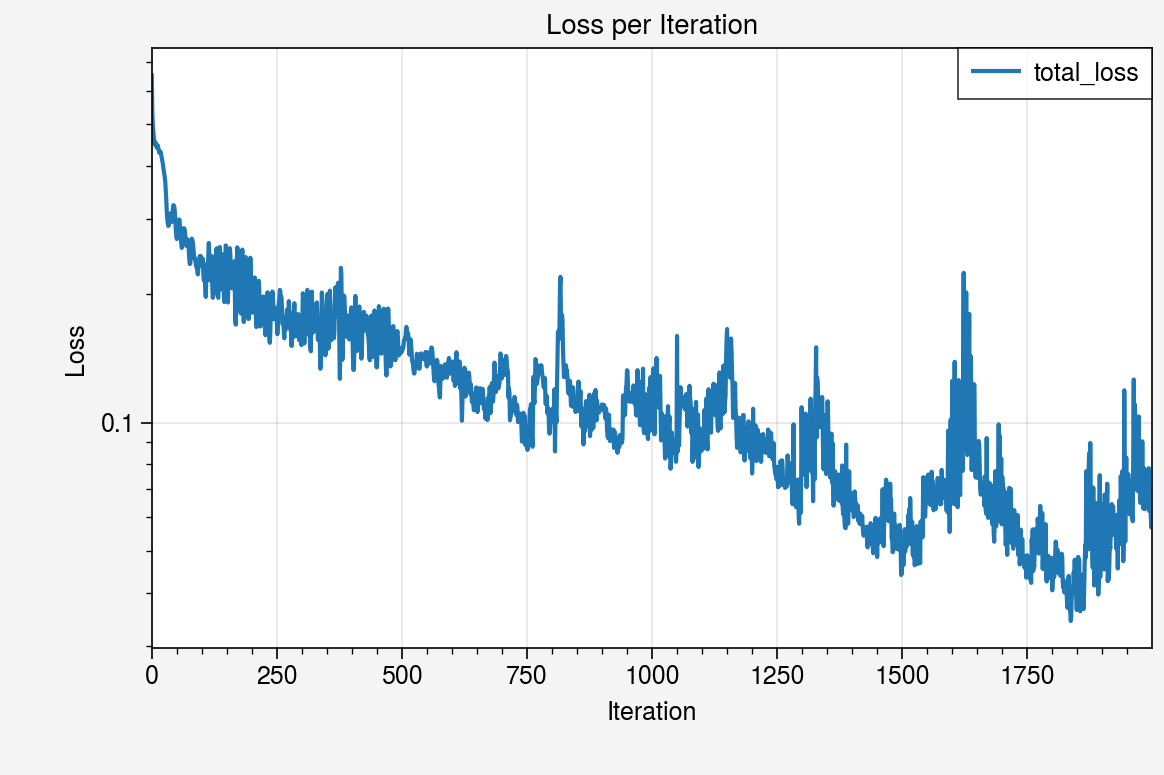

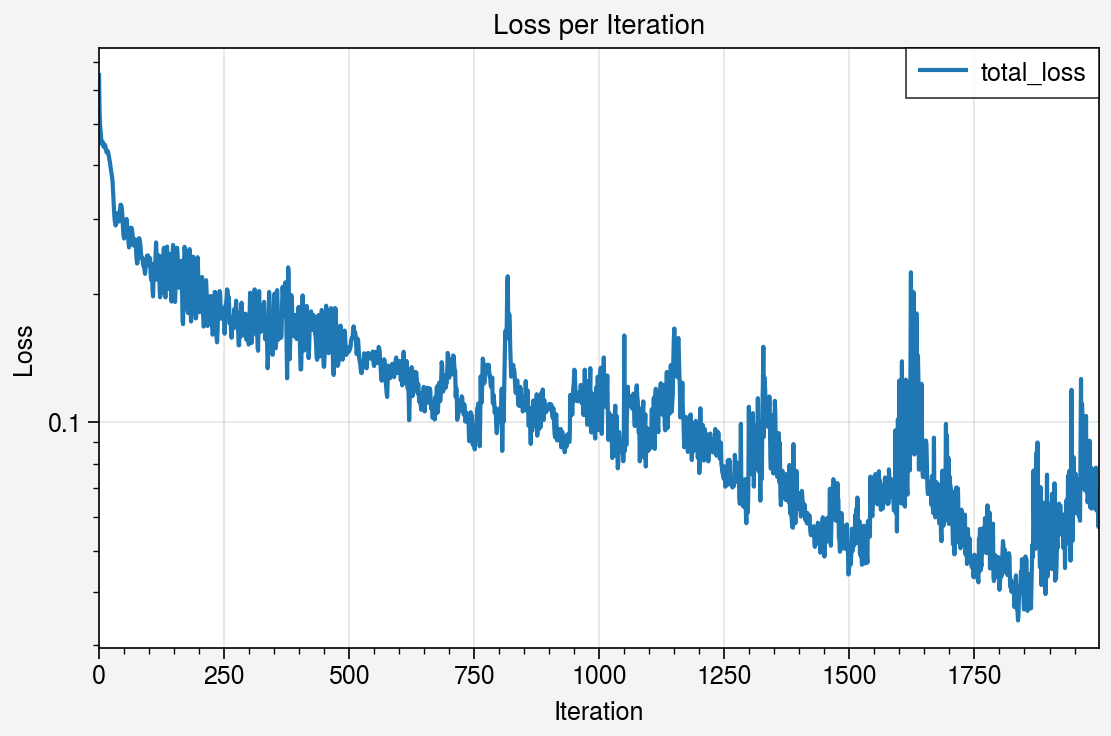

In [ ]:
pred.plot_loss_curve(keys=['total_loss'])